**#APP INSIGHT UNLOCKED**

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
import seaborn as sns

In [67]:
# Read CSV file
df=pd.read_csv("/content/googleplaystore.csv")

In [68]:
#Display Dataset
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [69]:
#Display information of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [70]:
#Checking for null values in Dataset
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [71]:
#finding rating median and repalcing null by median
df['Rating']=df.groupby('Category')['Rating'].transform(lambda x:x.fillna(x.median()))

In [72]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [73]:
#Drop the nulls of current version and Android Version
df.dropna(subset=['Current Ver','Android Ver'],inplace=True)

In [74]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,0
Genres,0


In [75]:
#Replaces a null in type Column by mode value
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])

In [76]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [77]:
#finding duplicates
df.duplicated().sum()

np.int64(483)

In [78]:
#drop duplicates
df=df.drop_duplicates()

In [79]:
#finding shape of Dataset
df.shape

(10347, 13)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10347 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10347 non-null  object 
 1   Category        10347 non-null  object 
 2   Rating          10347 non-null  float64
 3   Reviews         10347 non-null  object 
 4   Size            10347 non-null  object 
 5   Installs        10347 non-null  object 
 6   Type            10347 non-null  object 
 7   Price           10347 non-null  object 
 8   Content Rating  10347 non-null  object 
 9   Genres          10347 non-null  object 
 10  Last Updated    10347 non-null  object 
 11  Current Ver     10347 non-null  object 
 12  Android Ver     10347 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [81]:
#changing datatype of Rating column
df['Rating']=df['Rating'].astype(int)

/tmp/ipykernel_1645/3732457733.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating']=df['Rating'].astype(int)


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10347 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   App             10347 non-null  object
 1   Category        10347 non-null  object
 2   Rating          10347 non-null  int64 
 3   Reviews         10347 non-null  object
 4   Size            10347 non-null  object
 5   Installs        10347 non-null  object
 6   Type            10347 non-null  object
 7   Price           10347 non-null  object
 8   Content Rating  10347 non-null  object
 9   Genres          10347 non-null  object
 10  Last Updated    10347 non-null  object
 11  Current Ver     10347 non-null  object
 12  Android Ver     10347 non-null  object
dtypes: int64(1), object(12)
memory usage: 1.1+ MB


In [83]:
#change data type of Installs column
df['Installs']=df['Installs'].str.replace('+','')
df['Installs']=df['Installs'].str.replace(',','')

/tmp/ipykernel_1645/2115051348.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs']=df['Installs'].str.replace('+','')
/tmp/ipykernel_1645/2115051348.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs']=df['Installs'].str.replace(',','')


In [84]:
#display unique values of Installs column
print(df['Installs'].unique())

['10000' '500000' '5000000' '50000000' '100000' '50000' '1000000'
 '10000000' '5000' '100000000' '1000000000' '1000' '500000000' '50' '100'
 '500' '10' '1' '5' '0']


In [85]:
#Change datatype of Installs column to integer
df['Installs'] = df['Installs'].astype(int)


/tmp/ipykernel_1645/4069623937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Installs'] = df['Installs'].astype(int)


In [86]:
#Display unique valiues in Price Column
print(df['Price'].unique())

['0' '$4.99' '$3.99' '$6.99' '$1.49' '$2.99' '$7.99' '$5.99' '$3.49'
 '$1.99' '$9.99' '$7.49' '$0.99' '$9.00' '$5.49' '$10.00' '$24.99'
 '$11.99' '$79.99' '$16.99' '$14.99' '$1.00' '$29.99' '$12.99' '$2.49'
 '$10.99' '$1.50' '$19.99' '$15.99' '$33.99' '$74.99' '$39.99' '$3.95'
 '$4.49' '$1.70' '$8.99' '$2.00' '$3.88' '$25.99' '$399.99' '$17.99'
 '$400.00' '$3.02' '$1.76' '$4.84' '$4.77' '$1.61' '$2.50' '$1.59' '$6.49'
 '$1.29' '$5.00' '$13.99' '$299.99' '$379.99' '$37.99' '$18.99' '$389.99'
 '$19.90' '$8.49' '$1.75' '$14.00' '$4.85' '$46.99' '$109.99' '$154.99'
 '$3.08' '$2.59' '$4.80' '$1.96' '$19.40' '$3.90' '$4.59' '$15.46' '$3.04'
 '$4.29' '$2.60' '$3.28' '$4.60' '$28.99' '$2.95' '$2.90' '$1.97'
 '$200.00' '$89.99' '$2.56' '$30.99' '$3.61' '$394.99' '$1.26' '$1.20'
 '$1.04']


In [87]:
#Replacing "$" to " " in Price column
df['Price']=df['Price'].str.replace('$','', regex=True)


/tmp/ipykernel_1645/4036252097.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price']=df['Price'].str.replace('$','', regex=True)


In [88]:
#Counts every column type in Genres col
print(df['Genres'].value_counts())

Genres
Tools                       840
Entertainment               587
Education                   526
Business                    427
Medical                     408
                           ... 
Role Playing;Brain Games      1
Strategy;Education            1
Racing;Pretend Play           1
Communication;Creativity      1
Strategy;Creativity           1
Name: count, Length: 119, dtype: int64


In [89]:
#Replace operation in genres
df['Genres']=df['Genres'].str.replace(';',' and ')

/tmp/ipykernel_1645/2024070637.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Genres']=df['Genres'].str.replace(';',' and ')


In [90]:
#datatype updated to datetime of Last updated column
df['Last Updated']=pd.to_datetime(df['Last Updated'])

/tmp/ipykernel_1645/954337815.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Last Updated']=pd.to_datetime(df['Last Updated'])


In [91]:
#replacing in size column
df['Size']=df['Size'].str.replace('M','000')
df['Size']=df['Size'].str.replace('k','')
df['Size']=df['Size'].replace('Varies with device',np.nan)

/tmp/ipykernel_1645/1038372048.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Size']=df['Size'].str.replace('M','000')
/tmp/ipykernel_1645/1038372048.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Size']=df['Size'].str.replace('k','')
/tmp/ipykernel_1645/1038372048.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

In [92]:
#Convert Datatype to Float
df['Size'] = df['Size'].astype('float')

/tmp/ipykernel_1645/3637757215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Size'] = df['Size'].astype('float')


In [93]:
#Fill  null values of size column with median

df['Size'] = df['Size'].fillna(df['Size'].median())

/tmp/ipykernel_1645/3443295925.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Size'] = df['Size'].fillna(df['Size'].median())


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10347 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10347 non-null  object        
 1   Category        10347 non-null  object        
 2   Rating          10347 non-null  int64         
 3   Reviews         10347 non-null  object        
 4   Size            10347 non-null  float64       
 5   Installs        10347 non-null  int64         
 6   Type            10347 non-null  object        
 7   Price           10347 non-null  object        
 8   Content Rating  10347 non-null  object        
 9   Genres          10347 non-null  object        
 10  Last Updated    10347 non-null  datetime64[ns]
 11  Current Ver     10347 non-null  object        
 12  Android Ver     10347 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(9)
memory usage: 1.1+ MB


**BASIC LEVEL QUESTION**

In [95]:
#1. mean of rating column
print(df['Rating'].mean().round(3))

3.806


In [96]:
#2.unique category of apps
print(df['Category'].unique())
print("No. of unique category:-",df['Category'].nunique())

['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION']
No. of unique category:- 33


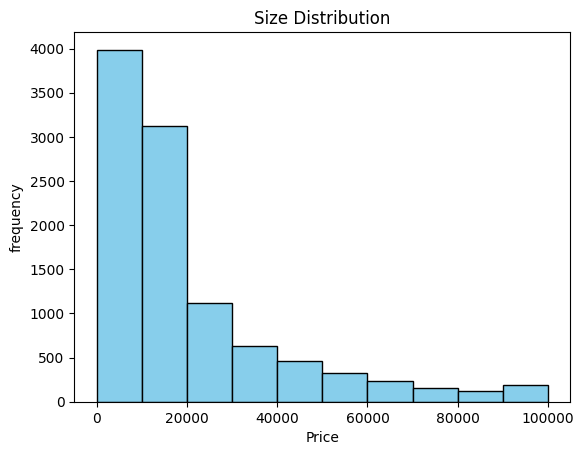

In [97]:
#3.distribution of app sizes
plt.hist(df['Size'],bins=10,color='skyblue',edgecolor='black')
plt.title('Size Distribution')
plt.xlabel('Price')
plt.ylabel('frequency')
plt.show()

In [98]:
#4.find free vs paid apps
df['Type'].value_counts()

,count
Type,
Free,9585
Paid,762


In [99]:
#5.most common content rating
(df['Content Rating'].mode())

,Content Rating
0,Everyone


In [100]:
#6. most five installed apps
df.sort_values(by='Installs', ascending = False).head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3127,Google Street View,TRAVEL_AND_LOCAL,4,2129689,13000.0,1000000000,Free,0,Everyone,Travel & Local,2018-08-06,Varies with device,Varies with device
9844,Google News,NEWS_AND_MAGAZINES,3,878065,13000.0,1000000000,Free,0,Teen,News & Magazines,2018-08-01,5.2.0,4.4 and up
335,Messenger – Text and Video Chat for Free,COMMUNICATION,4,56642847,13000.0,1000000000,Free,0,Everyone,Communication,2018-08-01,Varies with device,Varies with device
3816,Google News,NEWS_AND_MAGAZINES,3,877643,13000.0,1000000000,Free,0,Teen,News & Magazines,2018-08-01,5.2.0,4.4 and up
1700,Subway Surfers,GAME,4,27723193,76000.0,1000000000,Free,0,Everyone 10+,Arcade,2018-07-12,1.90.0,4.1 and up


In [101]:
#7.apps having rating 4 and above
df[df['Rating']>=4.0]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4,159,19000.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4,87510,8.7,5000000,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4,215644,25000.0,50000000,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4,967,2.8,100000,Free,0,Everyone,Art & Design and Creativity,2018-06-20,1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4,167,5.6,50000,Free,0,Everyone,Art & Design,2017-03-26,1.0,2.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4,38,53000.0,5000,Free,0,Everyone,Education,2017-07-25,1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5,4,3.6,100,Free,0,Everyone,Education,2018-07-06,1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,4,3,9.5,1000,Free,0,Everyone,Medical,2017-01-20,1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4,114,13000.0,1000,Free,0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device


In [102]:
df[df['Rating']>=4.0].shape[0]

8403

/tmp/ipykernel_1645/2614213755.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Reviews'] = df['Reviews'].astype(int)


<Axes: xlabel='Type'>

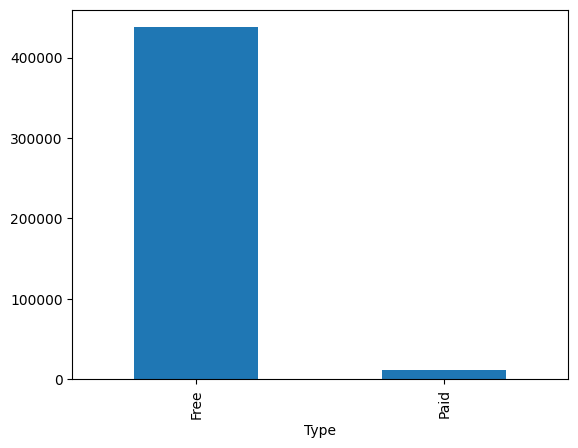

In [103]:
df['Reviews'] = df['Reviews'].astype(int)
df.groupby('Type')['Reviews'].mean().plot(kind='bar')

In [104]:
#9. avg app size
df.groupby('Category')['Size'].mean()

,Size
Category,
ART_AND_DESIGN,9784.020313
AUTO_AND_VEHICLES,17344.055294
BEAUTY,11172.347170
BOOKS_AND_REFERENCE,10673.610917
BUSINESS,11514.862061
COMICS,11469.495000
COMMUNICATION,10568.903005
DATING,13165.760204
EDUCATION,16994.171538


In [105]:

#10.apps last updated in 2018
df[df['Last Updated'].dt.year==(2018)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4,159,19000.0,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3,967,14000.0,500000,Free,0,Everyone,Art & Design and Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4,87510,8.7,5000000,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4,215644,25000.0,50000000,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4,967,2.8,100000,Free,0,Everyone,Art & Design and Creativity,2018-06-20,1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10826,Frim: get new friends on local chat rooms,SOCIAL,4,88486,13000.0,5000000,Free,0,Mature 17+,Social,2018-03-23,Varies with device,Varies with device
10827,Fr Agnel Ambarnath,FAMILY,4,117,13000.0,5000,Free,0,Everyone,Education,2018-06-13,2.0.20,4.0.3 and up
10831,payermonstationnement.fr,MAPS_AND_NAVIGATION,4,38,9.8,5000,Free,0,Everyone,Maps & Navigation,2018-06-13,2.0.148.0,4.0 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5,4,3.6,100,Free,0,Everyone,Education,2018-07-06,1.0,4.1 and up


**MEDIUM LEVEL QUESTIONS**

In [106]:
#1.correlation between no. of installs and the app ratings
df[['Installs','Rating']].corr()

,Installs,Rating
Installs,1.000000,0.045597
Rating,0.045597,1.000000


In [107]:
#2. App category having highest avg rating
a=df.groupby('Category')['Rating'].mean()
a.sort_values(ascending=False).head(1)

,Rating
Category,
EVENTS,4.03125


In [108]:
#3.price of app affects its avg rating
paid_df=df[df['Type']=='Paid']
results=paid_df.groupby('Price')['Rating'].mean()
results

,Rating
Price,
$0.99,3.944444
$1.00,4.000000
$1.04,4.000000
$1.20,4.000000
$1.26,4.000000
...,...
$8.49,3.500000
$8.99,3.400000
$89.99,4.000000


/tmp/ipykernel_1645/1010774395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df,x='Content Rating',y='Rating',palette='coolwarm')


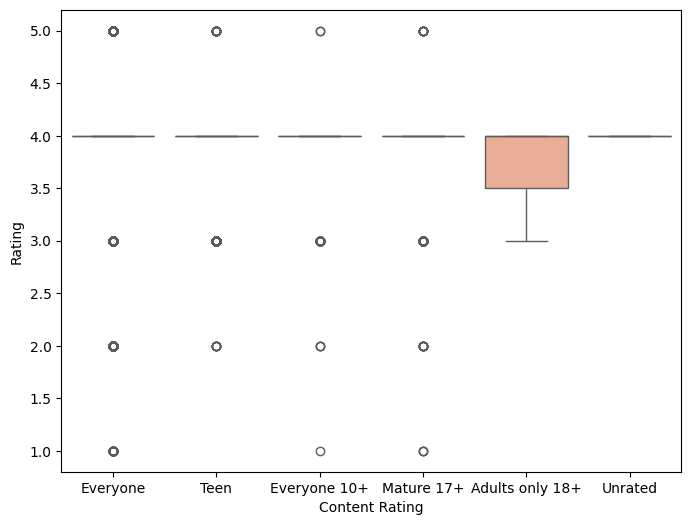

In [109]:
#4.distribution of app rating across different cntent rating
plt.figure(figsize=(8,6))
sns.boxplot(df,x='Content Rating',y='Rating',palette='coolwarm')
plt.show()

In [110]:
#5.Genres have most apps over 1 millions installs
df[df['Installs'] >= 1000000]['Genres'].value_counts()

,count
Genres,
Tools,288
Action,237
Photography,213
Communication,191
Productivity,180
...,...
Sports and Action & Adventure,1
Role Playing and Brain Games,1
Racing and Pretend Play,1


In [111]:
#6.how frequently apps updated
df = df.sort_values(by=['App', 'Last Updated'])

# Calculate difference between consecutive updates for each app
df['Days Between Updates'] = df.groupby('App')['Last Updated'].diff().dt.days

print(df)

                                                   App       Category  Rating  \
8884              "i DT" Fútbol. Todos Somos Técnicos.         SPORTS       4   
8532                     +Download 4 Instagram Twitter         SOCIAL       4   
324                         - Free Comics - Comic Apps         COMICS       3   
4541                                                .R          TOOLS       4   
4636                                            /u/app  COMMUNICATION       4   
...                                                ...            ...     ...   
6334                           뽕티비 - 개인방송, 인터넷방송, BJ방송  VIDEO_PLAYERS       4   
4362                                        💎 I'm rich      LIFESTYLE       3   
2575     💘 WhatsLov: Smileys of love, stickers and GIF         SOCIAL       4   
7559  📏 Smart Ruler ↔️ cm/inch measuring for homework!          TOOLS       4   
882   🔥 Football Wallpapers 4K | Full HD Backgrounds 😍  ENTERTAINMENT       4   

      Reviews     Size  Ins

In [112]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Days Between Updates'],
      dtype='object')

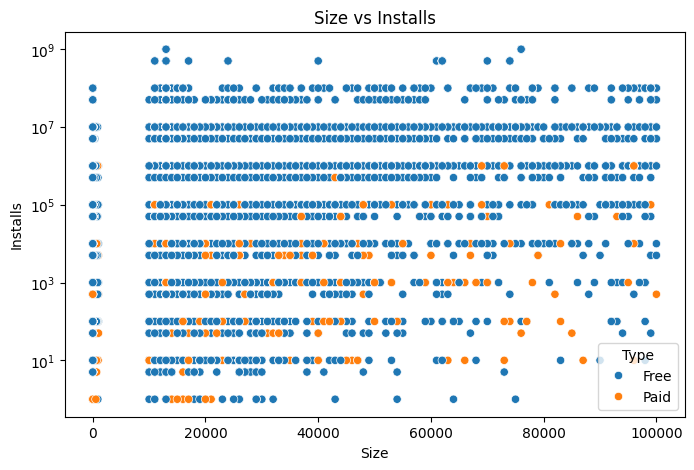

In [113]:
#7.impact of app size on number of install
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Size', y='Installs', hue='Type')
plt.yscale('log')
plt.title("Size vs Installs")
plt.show()

In [114]:
#8.App has highest no. of reviews and their ratings
df.sort_values(by='Reviews', ascending = False).head(1)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Days Between Updates
2544,Facebook,SOCIAL,4,78158306,13000.0,1000000000,Free,0,Teen,Social,2018-08-03,Varies with device,Varies with device,NaN


In [115]:
#9. Content Rating distribution differ between free and paid
df.pivot_table(values = 'App',index='Content Rating',columns='Type', aggfunc = 'count')

Type,Free,Paid
Content Rating,,
Adults only 18+,3.0,NaN
Everyone,7713.0,659.0
Everyone 10+,345.0,32.0
Mature 17+,428.0,19.0
Teen,1094.0,52.0
Unrated,2.0,NaN


In [116]:
#10.top 5 categories with most installs
df.groupby('Category')['Installs'].sum().sort_values(ascending = False).head(5)

,Installs
Category,
GAME,31544024415
COMMUNICATION,24152276251
SOCIAL,12513867902
PRODUCTIVITY,12463091369
TOOLS,11452271905


**ADVANCE LEVEL**

In [117]:
#1.top 10 apps with highest ratings,and comapre their no. of reveiws and installs
df.sort_values(by = 'Rating', ascending = False).head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Days Between Updates
5966,BC MVA Fines,BOOKS_AND_REFERENCE,5,5,7.2,50,Paid,$1.75,Everyone,Books & Reference,2015-10-08,1.0,4.1 and up,NaN
5268,AJ Rafael Music Lessons,FAMILY,5,1,8.2,10,Free,0,Everyone,Entertainment,2017-11-29,1.2.1,4.1 and up,NaN
5245,AJ RETAILS,SHOPPING,5,9,169.0,10,Free,0,Everyone,Shopping,2018-06-01,18060104,2.2 and up,NaN
6851,BV Mobile Apps,PRODUCTIVITY,5,3,4.8,100,Free,0,Everyone,Productivity,2018-06-05,2.0,4.2 and up,NaN
9246,Victoria EC,TOOLS,5,5,3.8,500,Free,0,Everyone,Tools,2018-03-30,1.283.0037,2.3.3 and up,NaN
7127,CB VIDEO VISION,PHOTOGRAPHY,5,13,2.6,100,Free,0,Everyone,Photography,2017-09-12,0.0.2,4.1 and up,NaN
7756,iReadMe,PRODUCTIVITY,5,8,22000.0,100,Free,0,Everyone,Productivity,2018-03-06,1.5,4.4 and up,NaN
2472,NCLEX Multi-topic Nursing Exam Review-Quiz & n...,MEDICAL,5,1,4.2,10,Free,0,Everyone,Medical,2018-07-24,1.0,4.0.3 and up,NaN
10349,Santa Fe Thrive,HEALTH_AND_FITNESS,5,2,8.3,50,Free,0,Everyone,Health & Fitness,2018-07-09,4.2.2,4.1 and up,NaN
9265,EC Mover,GAME,5,5,4.6,10,Free,0,Everyone,Racing,2018-08-01,1.11,4.0.3 and up,NaN


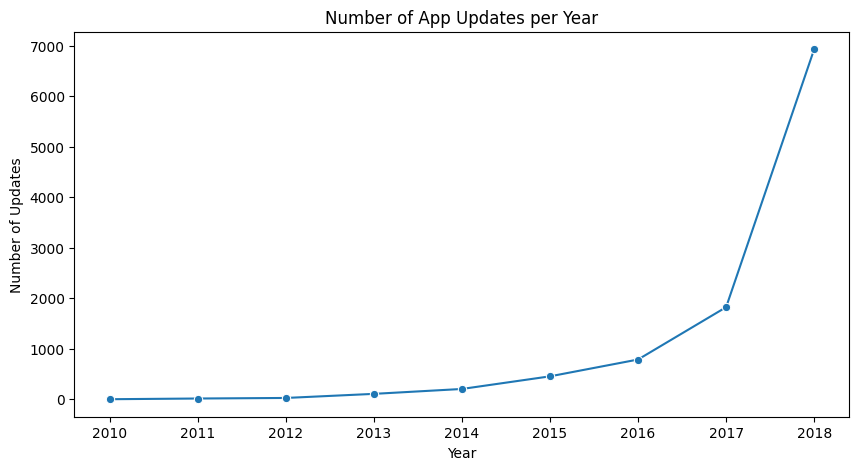

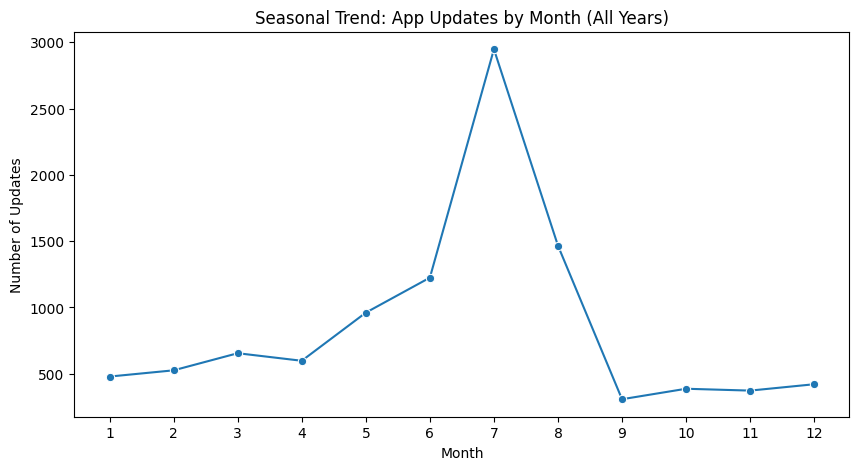

In [118]:
#2.analyze trends of app update over time.
df['Year'] = df['Last Updated'].dt.year
df['Month'] = df['Last Updated'].dt.month

updates_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=updates_per_year.index, y=updates_per_year.values, marker='o')
plt.title("Number of App Updates per Year")
plt.xlabel("Year")
plt.ylabel("Number of Updates")
plt.show()

updates_per_month = df['Month'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=updates_per_month.index, y=updates_per_month.values, marker='o')
plt.title("Seasonal Trend: App Updates by Month (All Years)")
plt.xlabel("Month")
plt.ylabel("Number of Updates")
plt.xticks(range(1,13))
plt.show()

/tmp/ipykernel_1645/1500477025.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_rating = df.groupby('Install_Bin')['Rating'].mean()


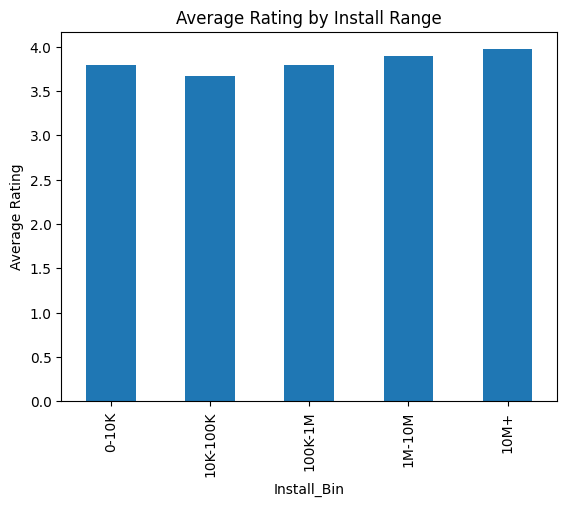

In [119]:
#3.how avg rating of apps cahnge with no. of installs
bins = [0, 10000, 100000, 1000000, 10000000, 100000000]
labels = ['0-10K', '10K-100K', '100K-1M', '1M-10M', '10M+']

df['Install_Bin'] = pd.cut(df['Installs'], bins=bins, labels=labels)
avg_rating = df.groupby('Install_Bin')['Rating'].mean()
avg_rating
avg_rating.plot(kind='bar')
plt.title("Average Rating by Install Range")
plt.ylabel("Average Rating")
plt.show()

In [120]:
#5.relation between app genre and user rating
genre_rating_summary = df.groupby('Genres')['Rating'].agg(['mean', 'median']).reset_index()

#Sort by mean rating to see which genres perform best
genre_rating_summary = genre_rating_summary.sort_values(by='mean', ascending=False)


print(genre_rating_summary.head(10))  # Top 10 genres by average rating


                                 Genres     mean  median
59                               Events  4.03125     4.0
4             Adventure and Brain Games  4.00000     4.0
5               Adventure and Education  4.00000     4.0
16         Board and Action & Adventure  4.00000     4.0
18               Board and Pretend Play  4.00000     4.0
10  Art & Design and Action & Adventure  4.00000     4.0
3      Adventure and Action & Adventure  4.00000     4.0
20     Books & Reference and Creativity  4.00000     4.0
32             Casual and Music & Video  4.00000     4.0
37         Communication and Creativity  4.00000     4.0
